# Import Libraries 📧

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
sns.set_style ("whitegrid")
import matplotlib.ticker as ticker

# Load Dataset 📁

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("SuperStore_Orders.csv", encoding="latin1")


Saving SuperStore_Orders.csv to SuperStore_Orders.csv


In [ ]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


# Data Preprocessing & Feature Engineering ⚒

In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

# Change type of order_date and ship_date from object to date_time

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [ ]:
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

# Remove ',' from sales column

In [ ]:
df['sales'] = df['sales'].str.replace(' ', '').str.replace(',', '')

# Convert sales Column to Numeric Data Type

In [ ]:
df['sales'] = pd.to_numeric(df['sales'])

# Now Every Column has its appropriate type

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

# Get Statistical Summary about Numeric Columns

In [ ]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931


# Check For Null Values

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


# Check For duplicated Values

In [ ]:
df.duplicated().sum()

np.int64(0)

# Shape of Dataset

In [ ]:
df.shape

(51290, 21)

# Create Shipping_days Column

In [ ]:
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

# Create Quarter Column

In [ ]:
df['quarter'] = df['order_date'].dt.quarter

# Create month_name Column

In [ ]:
df['month_name'] = df['order_date'].dt.month_name()

# Create order_day_of_week Column

In [ ]:
df['order_day_name'] = df['order_date'].dt.day_name()

# Create delivery_day_of_week Column

In [ ]:
df['delivery_day_name'] = df['ship_date'].dt.day_name()

# Create order_is_weekend Column

In [ ]:
df['order_is_weekend'] = df['order_day_name'].isin(["Saturday", "Sunday"])

# Create delivery_is_weekend Column

In [ ]:
df['delivery_is_weekend'] = df['delivery_day_name'].isin(["Saturday", "Sunday"])

# Create high_discount Column

In [ ]:
df['high_discount'] = df['discount'] >= 0.3

# Create Shipping_speed Column

In [ ]:
df['shipping_speed'] = pd.cut(
    df['shipping_days'],
    bins=[-1, 2, 5, df['shipping_days'].max()],
    labels=["Fast", "Medium", "Slow"]
)



# Convert object columns into categorical dtype for efficiency and clarity

In [ ]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

# Convert order_day_name

In [ ]:
df['order_day_name'] = pd.Categorical(
    df['order_day_name'], categories=days_order, ordered=True
)

# Convert delivery_day_name

In [ ]:
df['delivery_day_name'] = pd.Categorical (
    df['delivery_day_name'], categories=days_order, ordered=True
)

# Convert Quarter

In [ ]:
df['quarter'] = pd.Categorical(df['quarter'], categories=[1, 2, 3, 4],
                               ordered=True)

# Convert Month Name

In [ ]:
df['month_name'] = pd.Categorical(
    df['month_name'],
    categories=[
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ],
    ordered=True,
)

# Convert Order Priority

In [ ]:
df['order_priority'] = pd.Categorical(
    df['order_priority'], categories=["Low", "Medium", "High", "Critical"], ordered=True
)

# Convert Unordered Columns

In [ ]:
cols_unordered = [
    "segment",
    "state",
    "country",
    "market",
    "region",
    "category",
    "sub_category",
    "order_is_weekend",
    "delivery_is_weekend",
    "high_discount",
]

for col in cols_unordered:
  if col in df.columns:
    df[col] = df[col].astype("category")

# Check Data info & Stats after processing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             51290 non-null  object        
 1   order_date           51290 non-null  datetime64[ns]
 2   ship_date            51290 non-null  datetime64[ns]
 3   ship_mode            51290 non-null  object        
 4   customer_name        51290 non-null  object        
 5   segment              51290 non-null  object        
 6   state                51290 non-null  object        
 7   country              51290 non-null  object        
 8   market               51290 non-null  object        
 9   region               51290 non-null  object        
 10  product_id           51290 non-null  object        
 11  category             51290 non-null  object        
 12  sub_category         51290 non-null  object        
 13  product_name         51290 non-

In [ ]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year,shipping_days
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208,3.969370
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000,0.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000,3.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000,4.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000,5.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000,7.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931,1.729437


# EDA 📊

# Total Sales

In [ ]:
total_sales = df['sales'].sum()

print(f"Total Sales : ${total_sales:,.0f}")

Total Sales : $12,642,905


# Total Profit

In [ ]:
total_profit =df['profit'].sum()

print(f'Total Profit : ${total_profit:,.0f}')

Total Profit : $1,469,035


# Average Profit Margin

In [ ]:
profit_margin = (total_profit / total_sales) * 100

print(f'Profit Margin: {profit_margin:.2f}%')

Profit Margin: 11.62%


# Average Order Value (AOV)

In [ ]:
aov = df['sales'].sum() / df['order_id'].nunique()

print(f'Average Order Value (AOV) : ${aov:.2f}')

Average Order Value (AOV) : $505.01


# Number of Order

In [ ]:
total_orders = df['order_id'].nunique()

print(f'Total Orders: {total_orders}')

Total Orders: 25035


# Number of Unique Customers

In [ ]:
unique_customers = df['customer_name'].nunique()

print(f'Unique Customers: {unique_customers}')

Unique Customers: 795


# Number of Products Sold

In [ ]:
unique_products = df['product_id'].nunique()

print(f"Unique Products: {unique_products}")

Unique Products: 10292


# Repeat Customer Count

In [ ]:
repeat_customers = df.groupby('customer_name')["order_id"].nunique()
repeat_customer_count = (repeat_customers > 1).sum()

print(
    f"Repeat Customers: {repeat_customer_count} / {unique_customers} ({(repeat_customer_count/unique_customers)*100:.2f}%)"
)

Repeat Customers: 795 / 795 (100.00%)


# Average Shipping Days

In [ ]:
avg_shipping_days = df['shipping_days'].mean()

print(f'Average Shipping Days : {avg_shipping_days:.2f} days')

Average Shipping Days : 3.97 days


# Top 10 Selling Products

In [ ]:
top10_products = (
    df.groupby ( [ 'product_name', 'category'], observed=False)['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top10_products

,product_name,category,sales
0,"Apple Smart Phone, Full Size",Technology,86936
1,"Cisco Smart Phone, Full Size",Technology,76441
2,"Motorola Smart Phone, Full Size",Technology,73159
3,"Nokia Smart Phone, Full Size",Technology,71904
4,Canon imageCLASS 2200 Advanced Copier,Technology,61600
5,"Hon Executive Leather Armchair, Adjustable",Furniture,58200
6,"Office Star Executive Leather Armchair, Adjust...",Furniture,50667
7,"Harbour Creations Executive Leather Armchair, ...",Furniture,50120
8,"Samsung Smart Phone, Cordless",Technology,48654
9,"Nokia Smart Phone, with Caller ID",Technology,47880


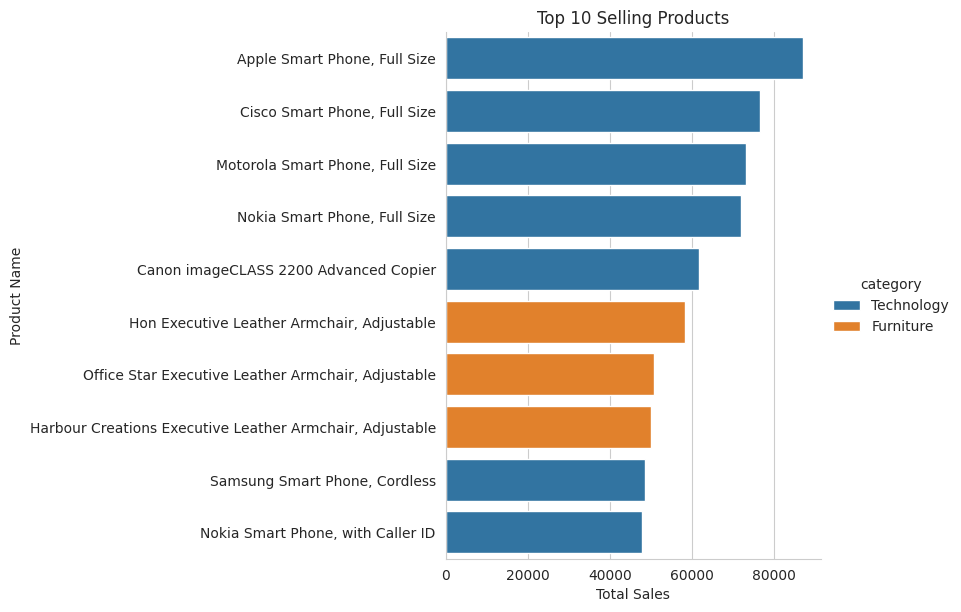

In [ ]:
g=sns.catplot(
    data=top10_products,
    x='sales',
    y='product_name',
    kind='bar',
    hue='category',
    errorbar=None,
    height=6,
    aspect=1.5,
)
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.title("Top 10 Selling Products")
plt.show()


# Top 10 Profit Products

In [ ]:
top10_profit_products = (
    df.groupby("product_name")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top10_profit_products)

                                        product_name      profit
0              Canon imageCLASS 2200 Advanced Copier  25199.9280
1                       Cisco Smart Phone, Full Size  17238.5206
2                    Motorola Smart Phone, Full Size  17027.1130
3                                  Hoover Stove, Red  11807.9690
4               Sauder Classic Bookcase, Traditional  10672.0730
5  Harbour Creations Executive Leather Armchair, ...  10427.3260
6                       Nokia Smart Phone, Full Size   9938.1955
7                  Cisco Smart Phone, with Caller ID   9786.6408
8                  Nokia Smart Phone, with Caller ID   9465.3257
9                                 Belkin Router, USB   8955.0180


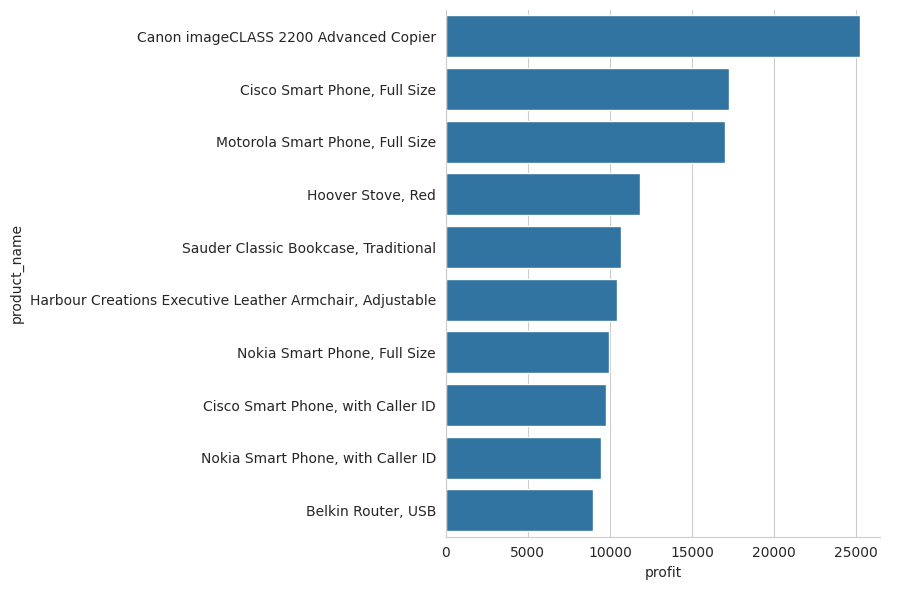

In [ ]:
sns.catplot(
    data=top10_profit_products,
    x="profit",
    y="product_name",
    kind="bar",
    height=6,
    aspect=1.5,
)
plt.show()

# Top 10 Products by Sales and Profit

In [ ]:
top10_products_by_sales_profit = (
    df.groupby("product_name")[["sales", "profit"]]
    .sum()
    .sort_values(by="sales", ascending=False)
    .head(10)
    .reset_index()
)
top10_products_by_sales_profit

,product_name,sales,profit
0,"Apple Smart Phone, Full Size",86936,5921.5786
1,"Cisco Smart Phone, Full Size",76441,17238.5206
2,"Motorola Smart Phone, Full Size",73159,17027.1130
3,"Nokia Smart Phone, Full Size",71904,9938.1955
4,Canon imageCLASS 2200 Advanced Copier,61600,25199.9280
5,"Hon Executive Leather Armchair, Adjustable",58200,5997.2541
6,"Office Star Executive Leather Armchair, Adjust...",50667,4710.9840
7,"Harbour Creations Executive Leather Armchair, ...",50120,10427.3260
8,"Samsung Smart Phone, Cordless",48654,-198.0900
9,"Nokia Smart Phone, with Caller ID",47880,9465.3257


# Top 10 Customers by Sales

In [ ]:
top10_customers = (
    df.groupby(['customer_name', 'market'], observed=False)['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print(top10_customers)

   customer_name market  sales
0    Sean Miller     US  25042
1   Tamara Chand     US  19050
2     Cari Sayre   APAC  16655
3   Susan Pistek     EU  16566
4    Vivek Grady   APAC  15654
5   Raymond Buch     US  15117
6   Peter Fuller   APAC  15063
7   Tom Ashbrook     US  14596
8    Barry Franz   APAC  14563
9  Adrian Barton     US  14476


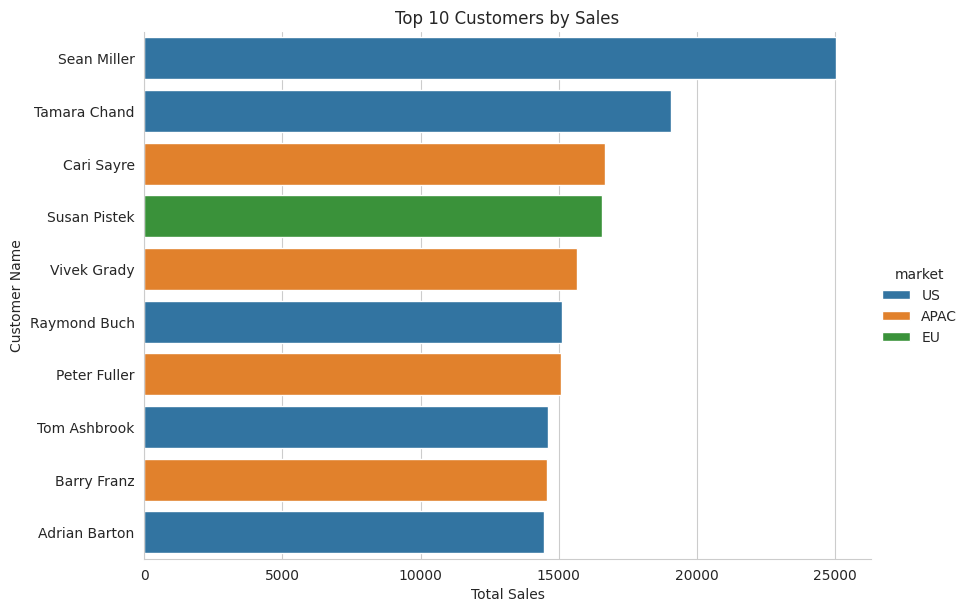

In [ ]:
sns.catplot(
    data=top10_customers,
    x="sales",
    y="customer_name",
    kind="bar",
    hue="market",
    errorbar=None,
    height=6,
    aspect=1.5,
)
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Sales")
plt.show()

# Top 10 Customers by Profit

In [ ]:
top10_customer_profitability = (
    df.groupby(['customer_name', 'segment'], observed=False)['profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top10_customer_profitability)

     customer_name      segment      profit
0     Tamara Chand    Corporate  8672.89890
1     Raymond Buch     Consumer  8453.04950
2     Sanjit Chand     Consumer  8205.37990
3     Hunter Lopez     Consumer  7816.56778
4      Bill Eplett  Home Office  7410.00530
5      Harry Marie    Corporate  6958.28640
6     Susan Pistek     Consumer  6484.40726
7  Mike Gockenbach     Consumer  6458.67620
8    Adrian Barton     Consumer  6417.28450
9     Tom Ashbrook  Home Office  6311.97910


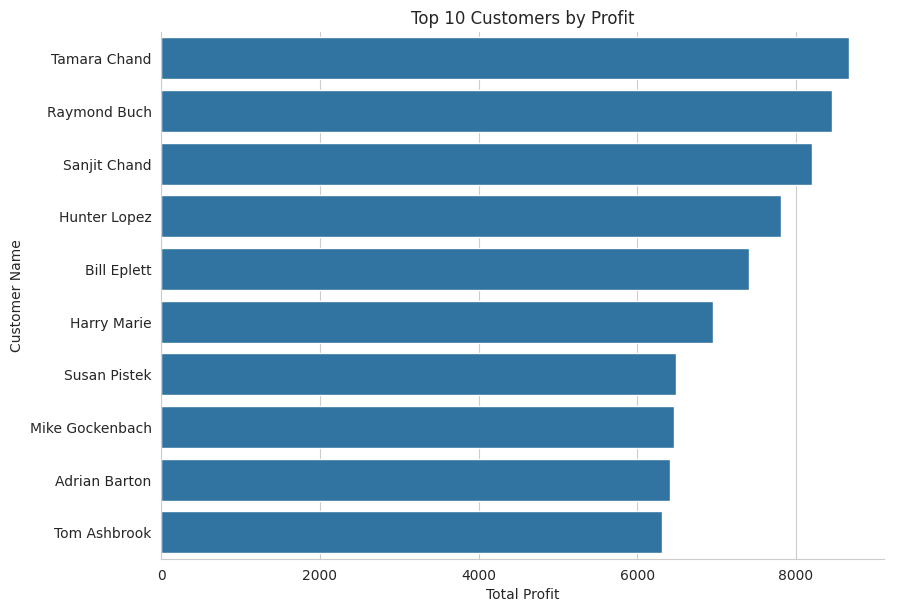

In [ ]:
sns.catplot(
    data=top10_customer_profitability,
    x="profit",
    y="customer_name",
    kind="bar",
    errorbar=None,
    height=6,
    aspect=1.5,
)
plt.xlabel("Total Profit")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Profit")
plt.show()

# Most Sold Products

In [ ]:
most_sold_products = (
    df.groupby(['product_name', 'category'], observed=False)
    ['order_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(most_sold_products)

                            product_name         category  order_id
0                                Staples  Office Supplies       211
1              Cardinal Index Tab, Clear  Office Supplies        92
2          Eldon File Cart, Single Width  Office Supplies        90
3         Rogers File Cart, Single Width  Office Supplies        84
4                 Ibico Index Tab, Clear  Office Supplies        83
5  Sanford Pencil Sharpener, Water Color  Office Supplies        80
6          Smead File Cart, Single Width  Office Supplies        77
7                  Acco Index Tab, Clear  Office Supplies        75
8  Stanley Pencil Sharpener, Water Color  Office Supplies        75
9                 Avery Index Tab, Clear  Office Supplies        74


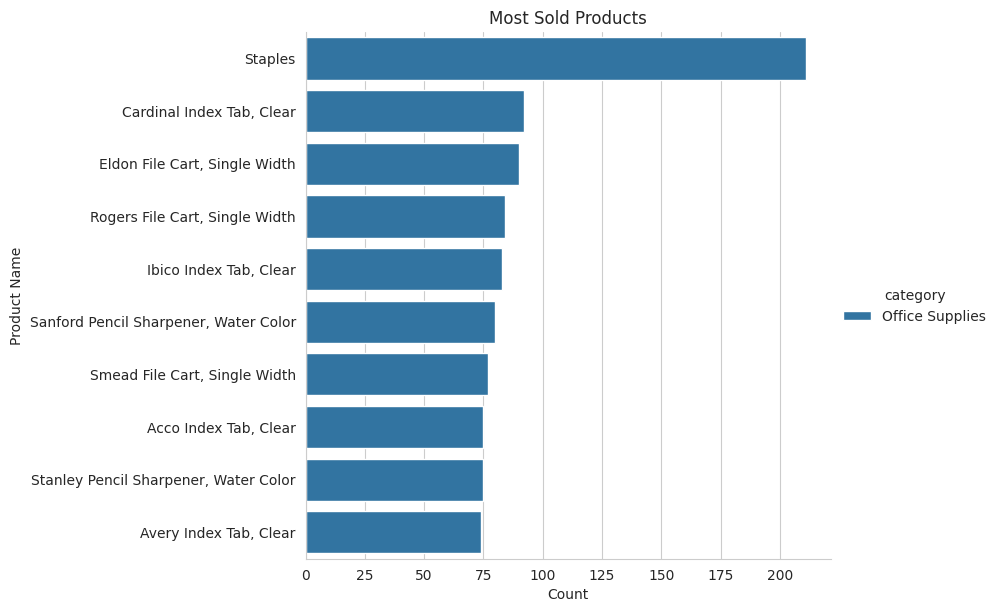

In [ ]:
sns.catplot(
    data=most_sold_products,
    y='product_name',
    x='order_id',
    kind='bar',
    height=6,
    aspect=1.5,
    hue='category',
)

plt.title("Most Sold Products")
plt.xlabel("Count")
plt.ylabel("Product Name")
plt.show()

# Most Profitable Products

In [ ]:
df.groupby("product_name")["profit"].sum().sort_values(ascending=False).head(10)

,profit
product_name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
"Cisco Smart Phone, Full Size",17238.5206
"Motorola Smart Phone, Full Size",17027.1130
"Hoover Stove, Red",11807.9690
"Sauder Classic Bookcase, Traditional",10672.0730
"Harbour Creations Executive Leather Armchair, Adjustable",10427.3260
"Nokia Smart Phone, Full Size",9938.1955
"Cisco Smart Phone, with Caller ID",9786.6408
"Nokia Smart Phone, with Caller ID",9465.3257


# Least Profitable Products

In [ ]:
loss_products = df[df["profit"] < 0]

loss_products.groupby(["product_name", "high_discount"], observed=False)[
    ["sales", "profit"]
].sum().sort_values(by="sales", ascending=False).head(10).reset_index()

,product_name,high_discount,sales,profit
0,Cisco TelePresence System EX90 Videoconferenci...,True,22638,-1811.07840
1,Lexmark MX611dhe Monochrome Laser Printer,True,13770,-5269.96900
2,"Samsung Smart Phone, VoIP",False,11516,-935.37600
3,"Hon Executive Leather Armchair, Black",False,11309,-622.40640
4,"Rogers Lockers, Blue",False,10296,-681.95620
5,"Hewlett Fax Machine, High-Speed",False,9804,-342.85328
6,"Smead Lockers, Wire Frame",False,8555,-205.96830
7,"Hon Executive Leather Armchair, Adjustable",False,8471,-548.10450
8,"SAFCO Executive Leather Armchair, Adjustable",False,8408,-1085.88960
9,"SAFCO Executive Leather Armchair, Red",False,8105,-1578.53300


# Top 10 states

In [ ]:
top10_states = (
    df.groupby(["state", "category"], observed=False)["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .reset_index()
)
print(top10_states)
top10_states["state"] = top10_states["state"].astype(str)

                     state         category   sales
0                  England       Technology  198990
1                  England  Office Supplies  162243
2               California       Technology  159279
3               California        Furniture  156069
4               California  Office Supplies  142383
5            Ile-de-France       Technology  129528
6                 New York       Technology  127496
7                  England        Furniture  123933
8            Ile-de-France  Office Supplies  110977
9          New South Wales        Furniture  106282
10         New South Wales       Technology  100906
11              Queensland       Technology   97780
12                New York        Furniture   93384
13                New York  Office Supplies   90034
14  North Rhine-Westphalia       Technology   84061
15              Queensland        Furniture   81340
16  North Rhine-Westphalia  Office Supplies   80380
17           Ile-de-France        Furniture   77313
18          

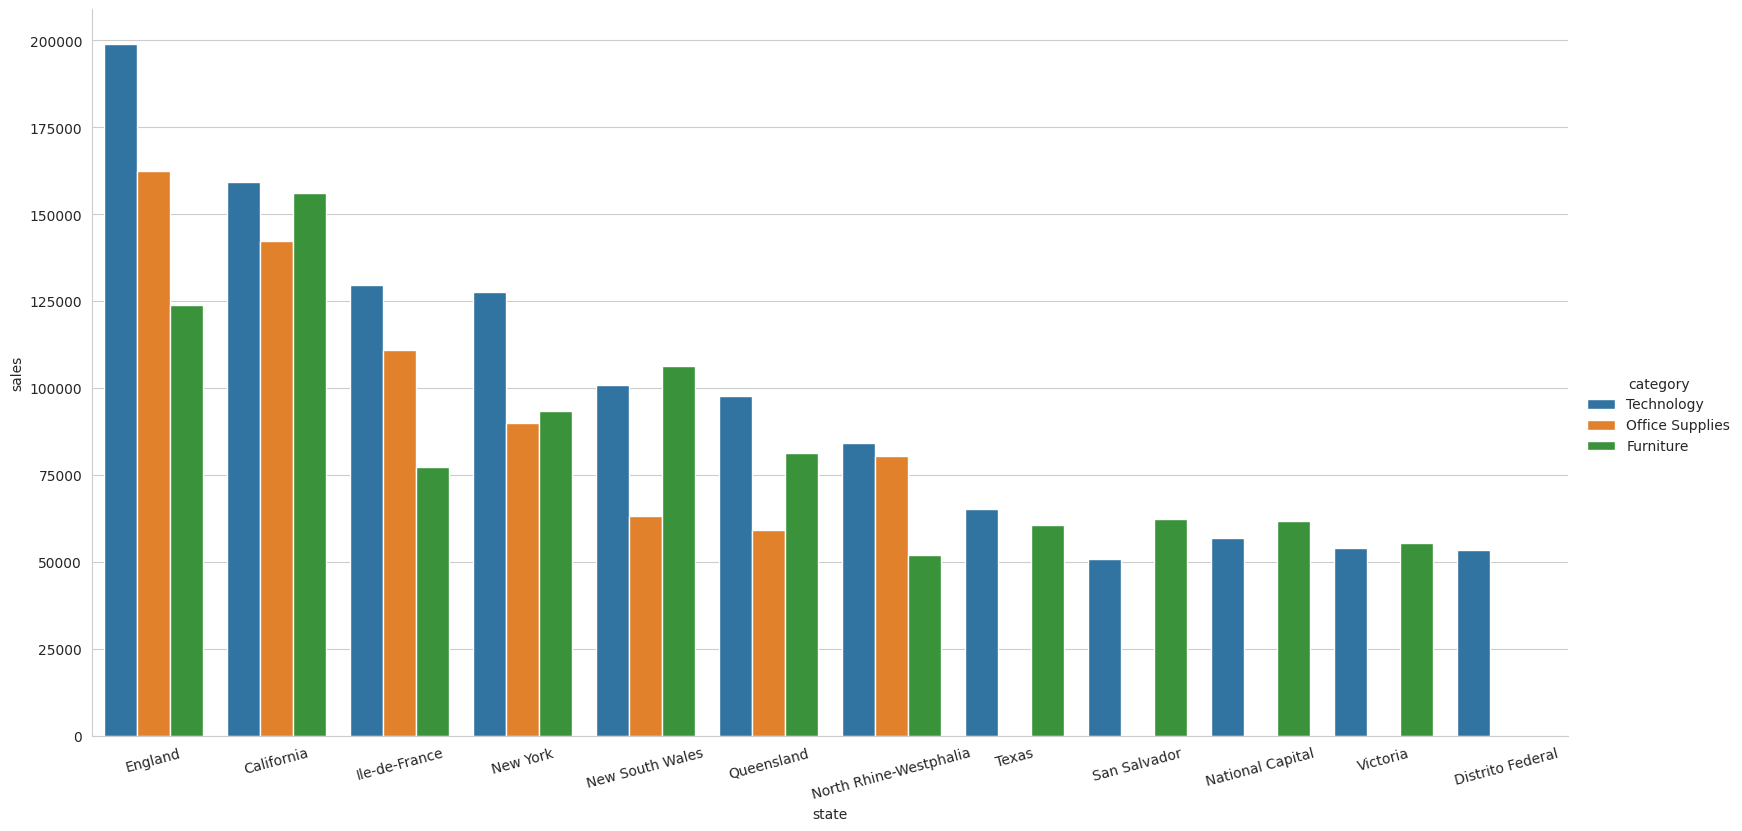

In [ ]:
sns.catplot(
    data=top10_states,
    y="sales",
    x="state",
    kind="bar",
    errorbar=None,
    height=8,
    aspect=2,
    hue="category",
)
plt.xticks(rotation=15)
plt.show()

# Top 10 Countries

In [ ]:
top10_countries = (
    df.groupby(["country", "category"], observed=False)["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .reset_index()
)
top10_countries["country"] = top10_countries["country"].astype("str")
print(top10_countries)

           country         category   sales
0    United States       Technology  836221
1    United States        Furniture  742006
2    United States  Office Supplies  719127
3        Australia       Technology  340215
4        Australia        Furniture  339245
5           France       Technology  312062
6           France  Office Supplies  304754
7            China        Furniture  276617
8            China       Technology  263520
9          Germany       Technology  262256
10          Mexico       Technology  246169
11       Australia  Office Supplies  245797
12           India       Technology  242266
13          France        Furniture  242114
14  United Kingdom       Technology  216748
15           India        Furniture  216062
16          Mexico        Furniture  215722
17         Germany  Office Supplies  205965
18  United Kingdom  Office Supplies  179369
19          Mexico  Office Supplies  160729
20         Germany        Furniture  160636
21           China  Office Suppl

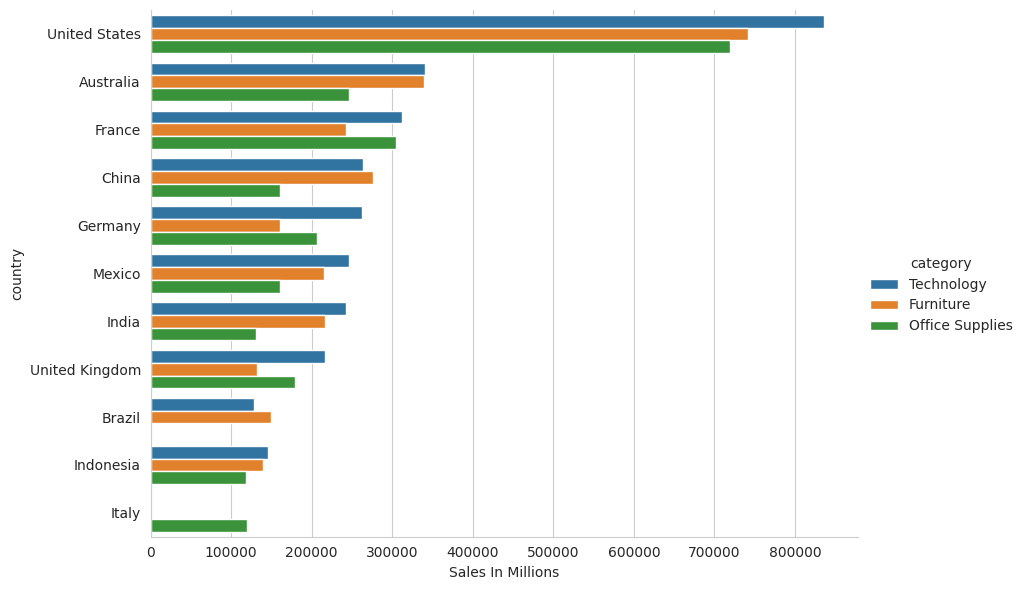

In [ ]:
sns.catplot(
    data=top10_countries,
    x="sales",
    y="country",
    kind="bar",
    errorbar=None,
    height=6,
    aspect=1.5,
    hue="category",
)
plt.xlabel("Sales In Millions")
plt.show()

# Top Markets

In [ ]:
top10_markets =(
    df.groupby('market', observed=False)['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top10_markets)
top10_markets['market'] = top10_markets['market'].astype('str')

   market    sales
0    APAC  3585833
1      EU  2938139
2      US  2297354
3   LATAM  2164687
4    EMEA   806184
5  Africa   783776
6  Canada    66932


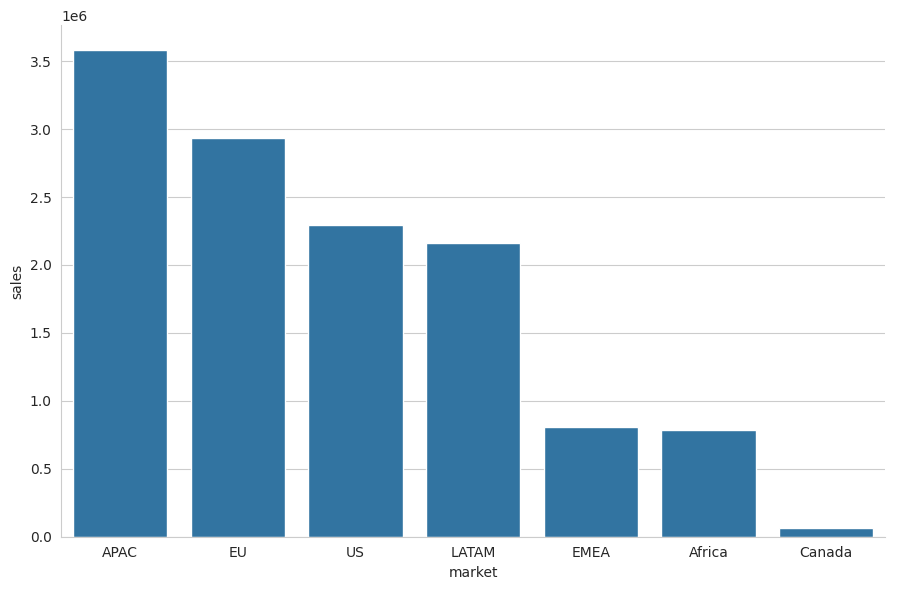

In [ ]:
sns.catplot(
    data=top10_markets,
    x="market",
    y="sales",
    kind="bar",
    errorbar=None,
    height=6,
    aspect=1.5,
)
plt.show()

# Top 10 Regions

In [ ]:
top10_regions = (
    df.groupby("region", observed=False)["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print(top10_regions)
top10_regions["region"] = top10_regions["region"].astype("str")

           region    sales
0         Central  2822399
1           South  1600960
2           North  1248192
3         Oceania  1100207
4  Southeast Asia   884438
5      North Asia   848349
6            EMEA   806184
7          Africa   783776
8    Central Asia   752839
9            West   725514


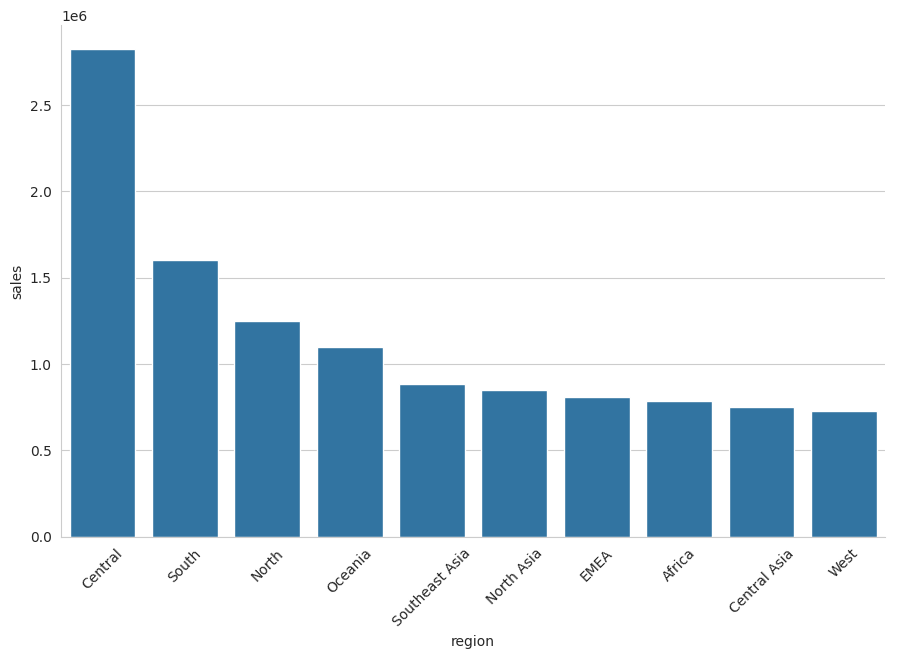

In [ ]:
sns.catplot(
    data=top10_regions,
    x="region",
    y="sales",
    kind="bar",
    errorbar=None,
    height=6,
    aspect=1.5,
)
plt.xticks(rotation=45)
plt.show()

# Order Date

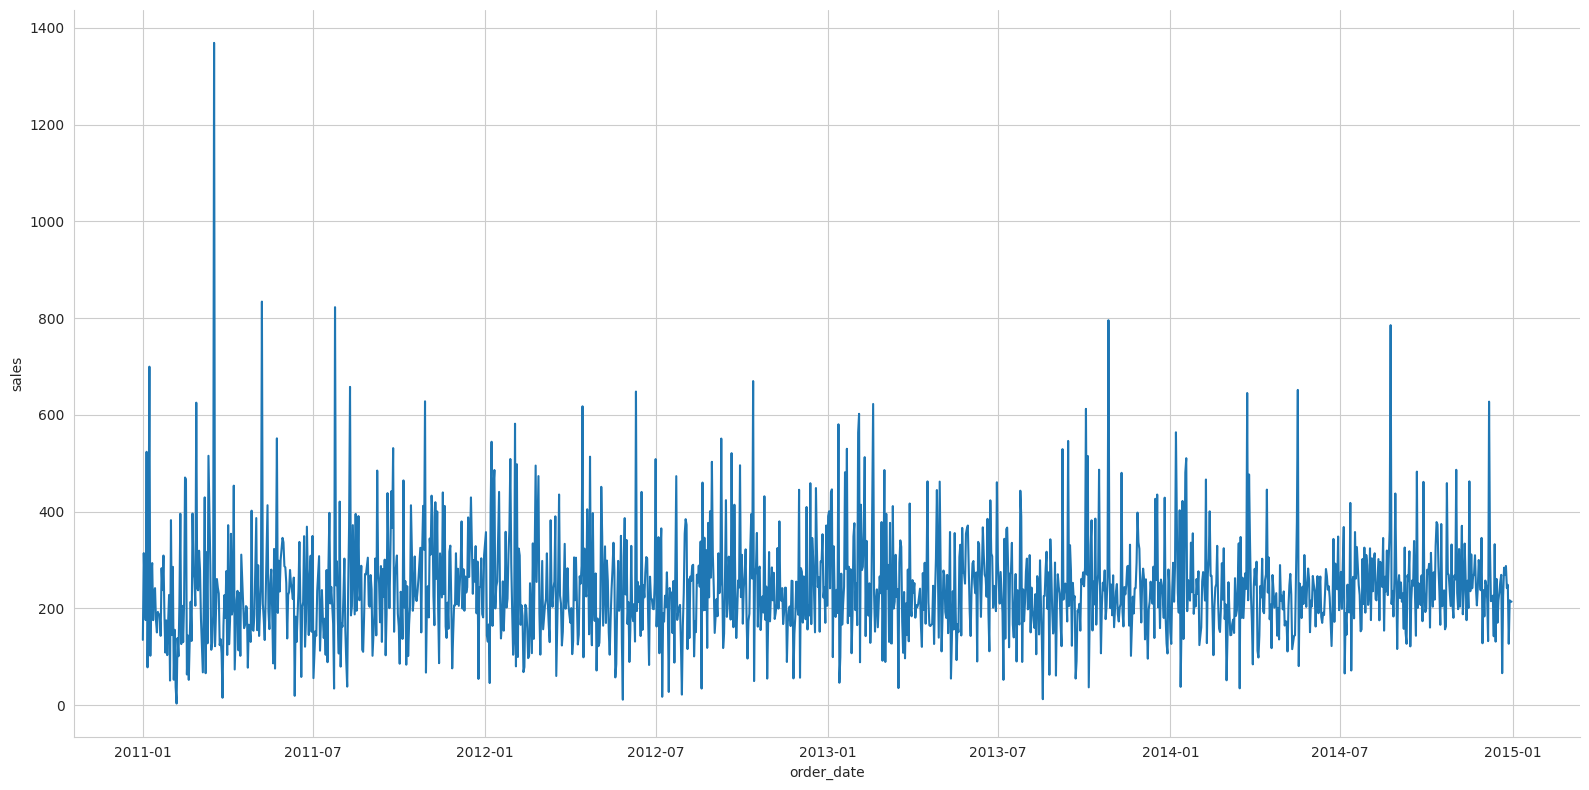

In [ ]:
sns.relplot(
    data=df, x="order_date", y="sales", kind="line", errorbar=None, height=8, aspect=2
)
plt.show()

# Weekends

In [ ]:
weekend_sales = (
    df.groupby("order_is_weekend", observed=False)["sales"].sum().reset_index()
)
print(weekend_sales)

   order_is_weekend     sales
0             False  11242617
1              True   1400288


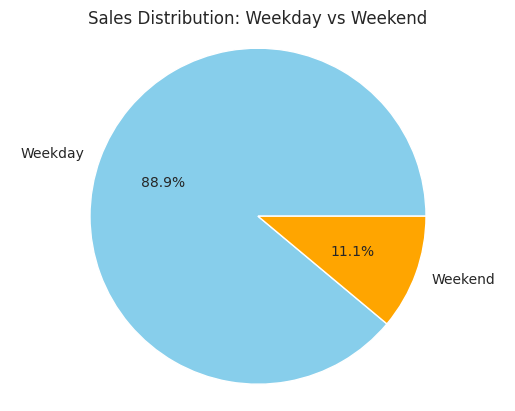

In [ ]:
plt.pie(
    weekend_sales["sales"],
    labels=["Weekday", "Weekend"],
    autopct="%1.1f%%",
    colors=["skyblue", "orange"],
)
plt.title("Sales Distribution: Weekday vs Weekend")
plt.axis("equal")
plt.show()

# Shipping Sales

In [ ]:
shipping_sales = (
    df.groupby("shipping_speed", observed=False)["sales"].sum().reset_index()
)
print(shipping_sales)

  shipping_speed    sales
0           Fast  2860775
1         Medium  7493133
2           Slow  2288997


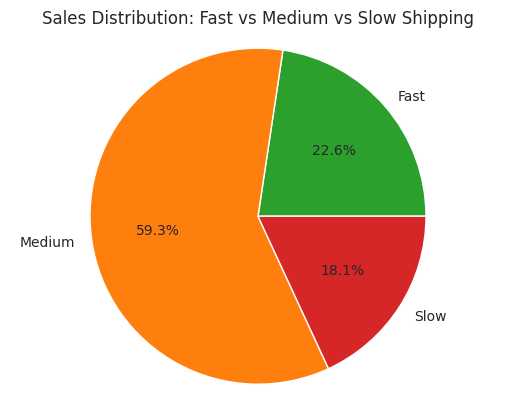

In [ ]:
plt.pie(
    shipping_sales["sales"],
    labels=["Fast", "Medium", "Slow"],
    autopct="%1.1f%%",
    colors=["#2ca02c", "#ff7f0e", "#d62728"],
)
plt.title("Sales Distribution: Fast vs Medium vs Slow Shipping")
plt.axis("equal")
plt.show()

# Shipping Vs Profit

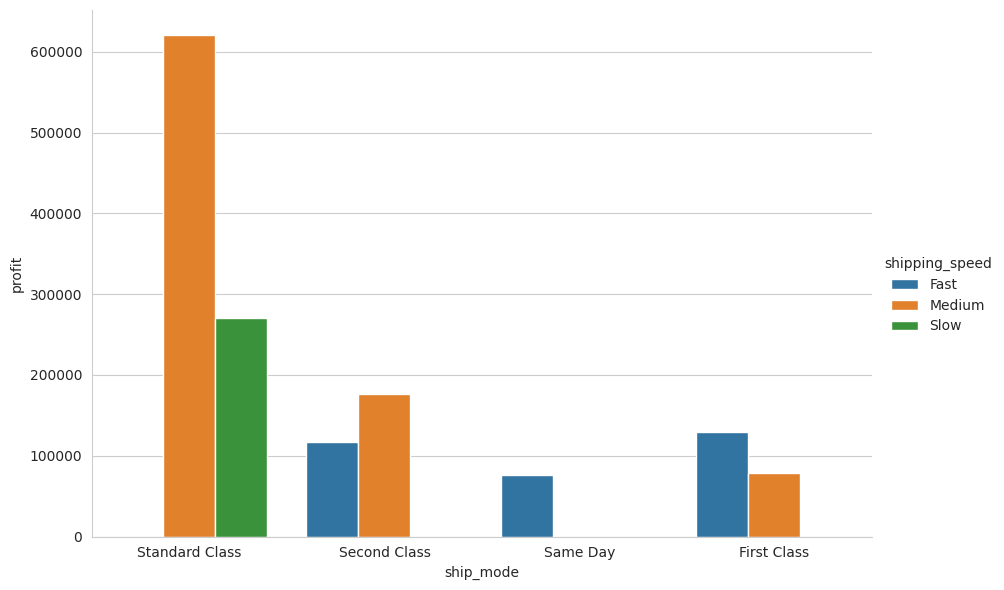

In [ ]:
sns.catplot(
    data=df,
    x="ship_mode",
    y="profit",
    kind="bar",
    estimator="sum",
    hue="shipping_speed",
    errorbar=None,
    height=6,
    aspect=1.5,
)
plt.show()

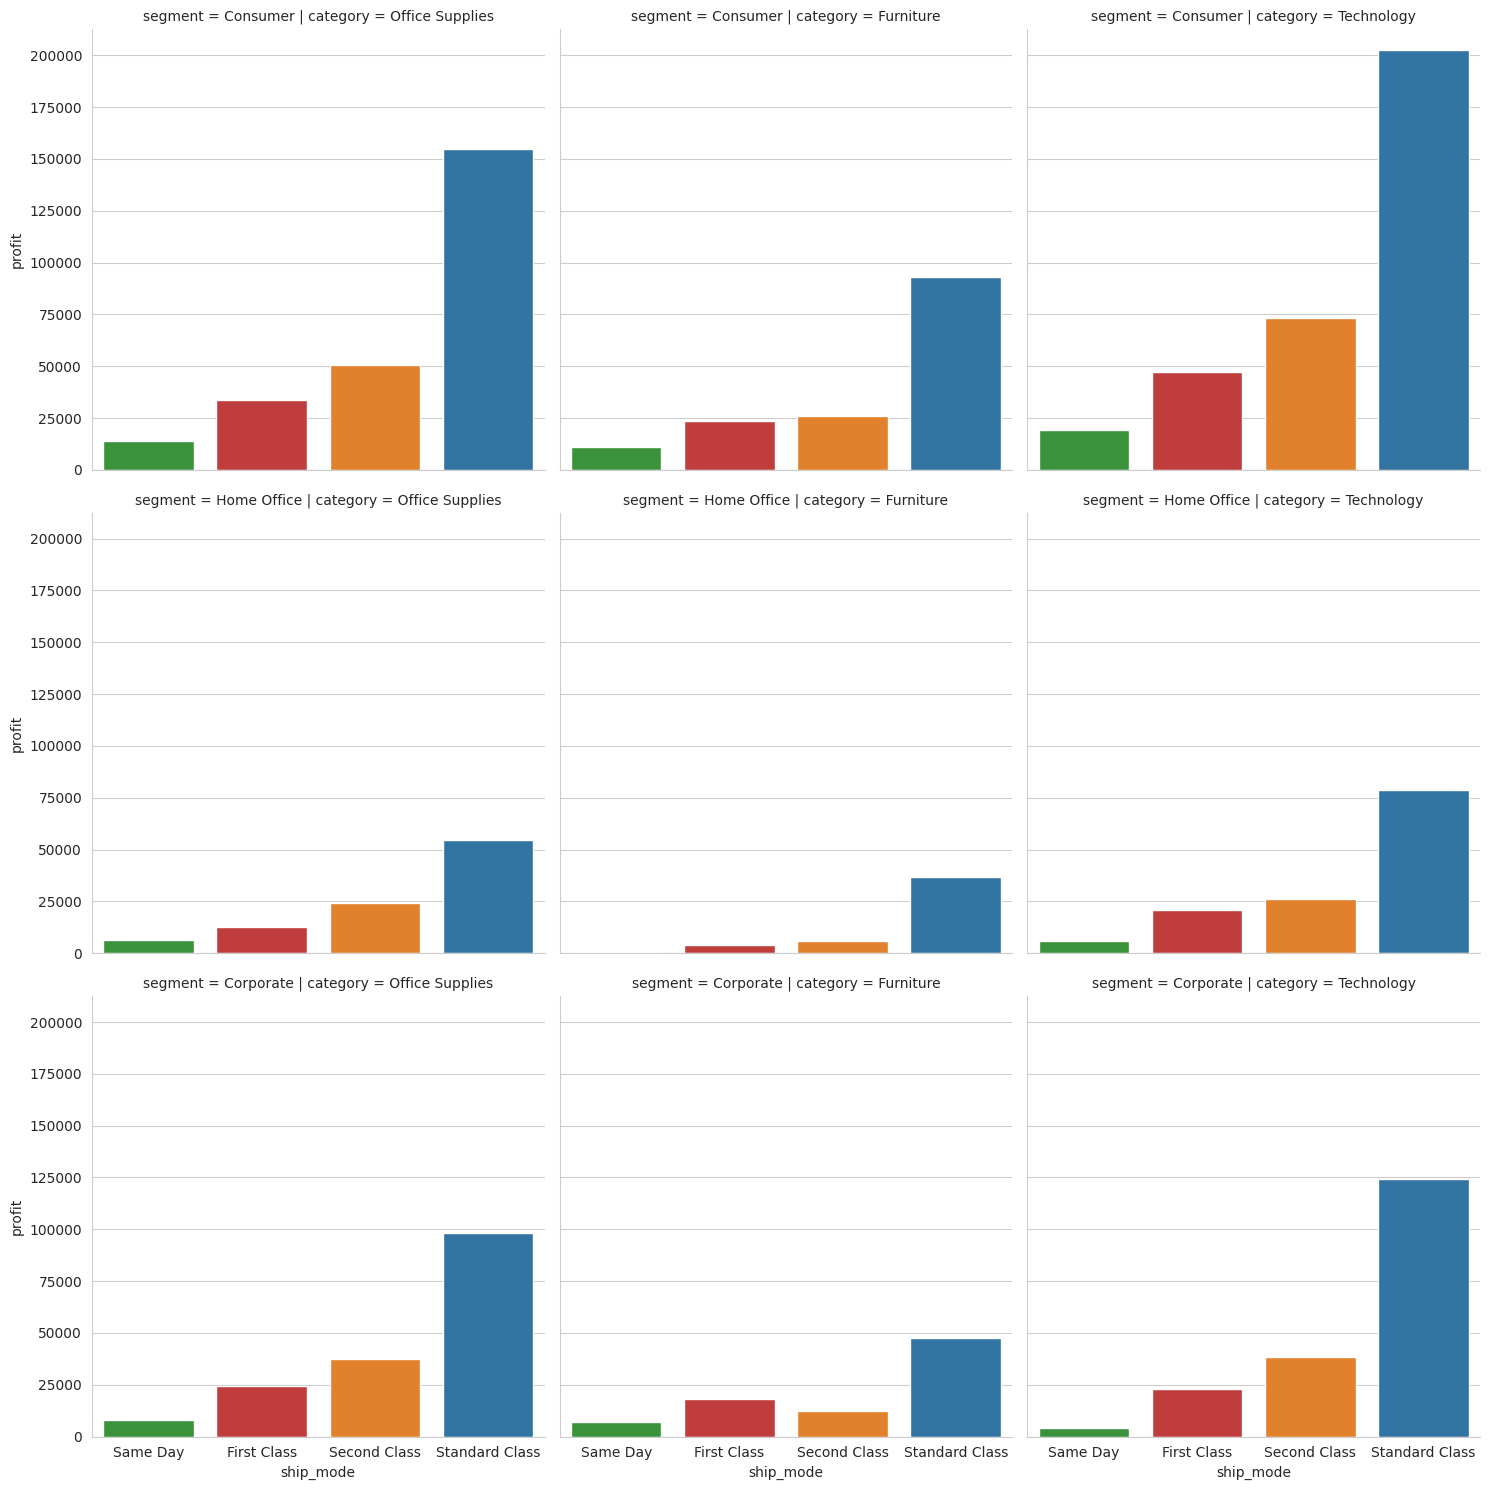

In [ ]:
sns.catplot(
    data=df,
    x="ship_mode",
    y="profit",
    kind="bar",
    estimator="sum",
    hue="ship_mode",
    errorbar=None,
    order=["Same Day", "First Class", "Second Class", "Standard Class"],
    col="category",
    row="segment",
)
plt.show()

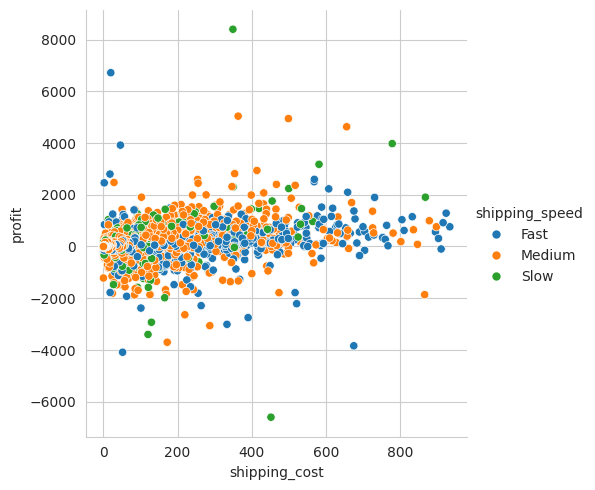

In [ ]:
sns.relplot(
    data=df, x="shipping_cost", y="profit", kind="scatter", hue="shipping_speed"
)
plt.show()

# Discounts

In [ ]:
disount_profit = (
    df.groupby("high_discount", observed=False)["profit"].sum().reset_index()
)
print(disount_profit)

   high_discount        profit
0          False  2.282247e+06
1           True -8.132123e+05


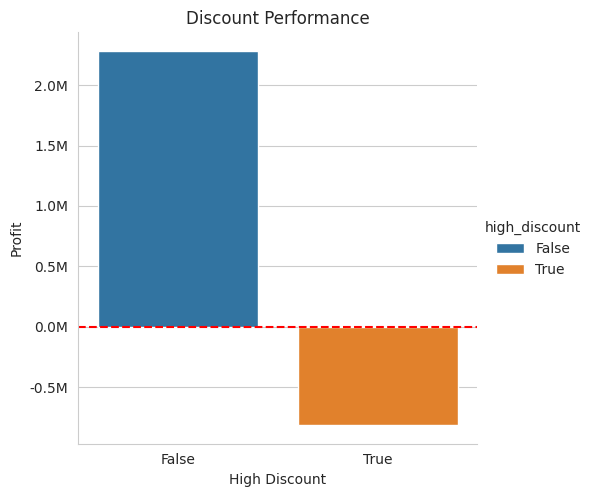

In [ ]:
sns.catplot(
    data=disount_profit,
    x="high_discount",
    y="profit",
    kind="bar",
    hue="high_discount",
    errorbar=None,
)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x*1e-6:.1f}M")
)
plt.axhline(0, color="red", linestyle="--")
plt.ylabel("Profit")
plt.title("Discount Performance")
plt.xlabel("High Discount")
plt.show()

In [ ]:
discount_summary = (
    df.groupby("high_discount", observed=False)
    .agg(products_count=("product_id", "count"), total_sales=("sales", "sum"))
    .reset_index()
)

total_count = discount_summary["products_count"].sum()
discount_summary["products_ratio"] = (
    (discount_summary["products_count"] / total_count) * 100
).round(2)


print(discount_summary)

   high_discount  products_count  total_sales  products_ratio
0          False           40589     10906290           79.14
1           True           10701      1736615           20.86


# Category

In [ ]:
cat_sales = df.groupby("category", observed=False)["sales"].sum().reset_index()
print(cat_sales)

          category    sales
0        Furniture  4110884
1  Office Supplies  3787330
2       Technology  4744691


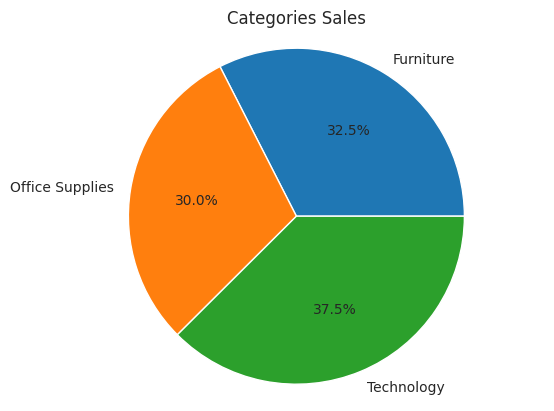

In [ ]:
plt.pie(cat_sales["sales"], labels=cat_sales["category"], autopct="%1.1f%%")

plt.title("Categories Sales")

plt.axis("equal")

plt.show()

# Sub-Categories

In [ ]:
sub_cat_sales = (
    df.groupby("sub_category", observed=False)["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print(sub_cat_sales)
sub_cat_sales["sub_category"] = sub_cat_sales["sub_category"].astype("str")

  sub_category    sales
0       Phones  1706874
1      Copiers  1509439
2       Chairs  1501682
3    Bookcases  1466559
4      Storage  1127124
5   Appliances  1011081
6     Machines   779071
7       Tables   757034
8  Accessories   749307
9      Binders   461952


In [ ]:
sns.catplot(
    data=sub_cat_sales,
    y="sub_category",
    x="sales",
    kind="bar",
    errorbar=None,
    hue="sub_category",
    height=6,
    aspect=1.5
)
plt.show()

# Categories Performance

In [ ]:
top_cat = (
    df.groupby("category", observed=False)[["sales", "profit"]]
    .sum()
    .sort_values(by="sales", ascending=False)
    .head(17)
    .reset_index()
)
top_cat

,category,sales,profit
0,Technology,4744691,663778.73318
1,Furniture,4110884,286782.25380
2,Office Supplies,3787330,518473.83430


In [ ]:
melted = pd.melt(
    top_cat,
    id_vars="category",
    value_vars=["sales", "profit"],
    var_name="Metric",
    value_name="Value",
)
melted

,category,Metric,Value
0,Technology,sales,4.744691e+06
1,Furniture,sales,4.110884e+06
2,Office Supplies,sales,3.787330e+06
3,Technology,profit,6.637787e+05
4,Furniture,profit,2.867823e+05
5,Office Supplies,profit,5.184738e+05


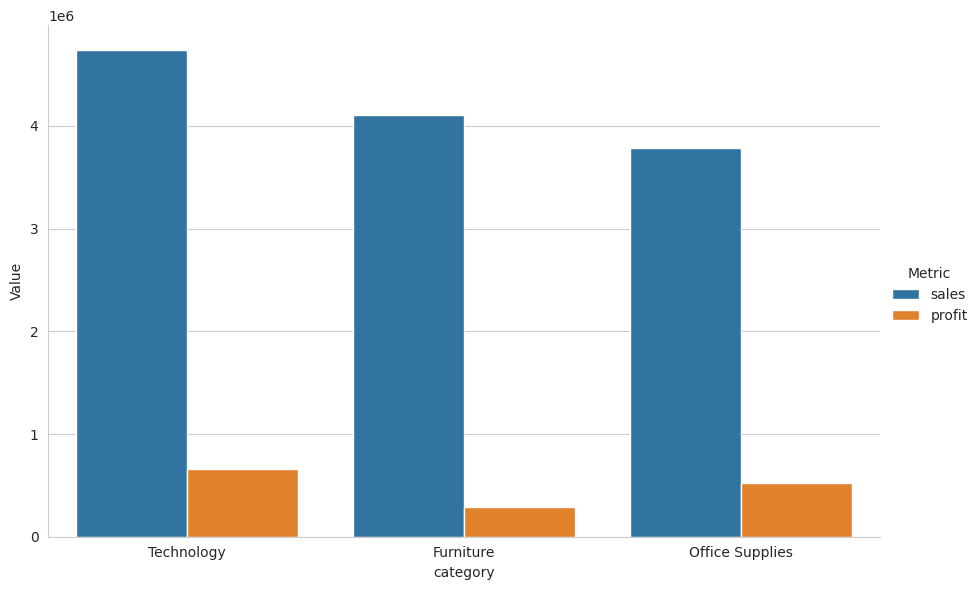

In [ ]:
sns.catplot(
    data=melted,
    x="category",
    y="Value",
    kind="bar",
    estimator="sum",
    hue="Metric",
    errorbar=None,
    order=melted["category"],
    height=6,
    aspect=1.5
)

plt.show()

# order_priority vs shipping_days

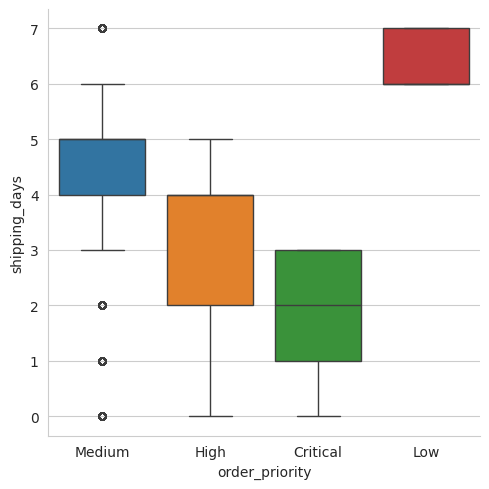

In [ ]:
sns.catplot(
    data=df, x="order_priority", y="shipping_days", kind="box", hue="order_priority"
)
plt.show()

# Discount vs Shipping Cost

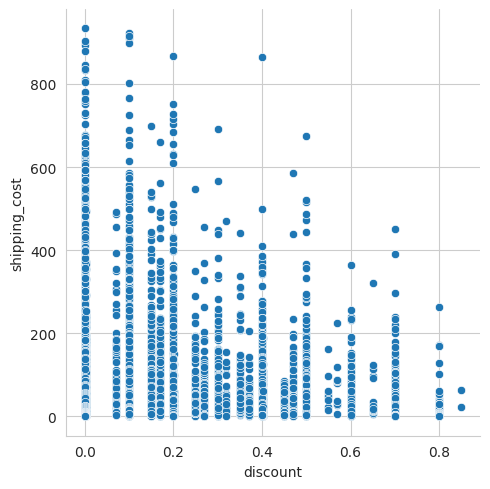

In [ ]:
sns.relplot(data=df, x="discount", y="shipping_cost", kind="scatter")
plt.show()

## Key Takeaways from the Analysis

Based on your analysis of the SuperStore Orders dataset, here are some key takeaways:

*   **Overall Performance:**
    *   Total Sales: $12,642,905
    *   Total Profit: $1,469,035
    *   Profit Margin: 11.62%
    *   Average Order Value (AOV): $505.01
    *   Total Orders: 25035
    *   Unique Customers: 795 (all of whom are repeat customers, indicating strong customer retention)
    *   Unique Products: 10292
    *   Average Shipping Days: 3.97 days

*   **Top Performers:**
    *   **Top 10 Selling Products:** Dominated by Technology and Furniture categories, with "Apple Smart Phone, Full Size" leading in sales.
    *   **Top 10 Profit Products:** "Canon imageCLASS 2200 Advanced Copier" is the most profitable product.
    *   **Top 10 Customers by Sales:** Sean Miller and Tamara Chand are the top customers by sales, with a mix of markets represented.
    *   **Top 10 Customers by Profit:** Tamara Chand and Raymond Buch are the most profitable customers.
    *   **Most Sold Products:** Staples is the most frequently sold product, followed by various office supplies.

*   **Loss-Making Products:** There are products with negative profit, particularly some high-value items like the "Cisco TelePresence System EX90 Videoconferencing Unit" and certain printers and furniture. These might warrant further investigation into pricing, costs, or discounts.

*   **Geographical Performance:**
    *   **Top 10 States:** England and California show high sales across multiple categories.
    *   **Top 10 Countries:** The United States has the highest sales, followed by Australia and France.
    *   **Top Markets:** APAC leads in sales, followed by EU and US.
    *   **Top Regions:** Central and South regions have the highest sales.

*   **Order and Shipping:**
    *   The majority of sales occur on weekdays (88.6%) compared to weekends (11.4%).
    *   Medium-speed shipping accounts for the largest portion of sales (59.4%).
    *   There appears to be a relationship between shipping mode, speed, and profit, which is explored in more detail in the `catplot` visualizations.
    *   The scatter plot of shipping cost vs profit suggests a general trend, but there are outliers.

*   **Discounts:**
    *   Applying high discounts (>= 0.3) results in significant negative profit, despite representing a smaller percentage of products (20.86%) and sales (13.73%). This highlights the importance of carefully considering discount strategies.

*   **Categories and Sub-Categories:**
    *   Technology is the top-performing category in terms of sales, followed by Furniture and Office Supplies.
    *   Within sub-categories, Phones, Copiers, and Chairs are the top performers by sales.
    *   The categories performance analysis shows that while Technology has the highest sales and profit, Furniture and Office Supplies also contribute significantly to sales, though with lower profit margins.

*   **Order Priority and Shipping Days:** The box plot shows a clear correlation between order priority and shipping days, with higher priority orders generally having shorter shipping times.

*   **Discount vs Shipping Cost:** The scatter plot shows a general trend, but there is no strong linear correlation between discount and shipping cost.